# 🏎️ Optimización de Hiperparámetros (Titanic)
En esta fase, dejamos atrás la configuración "de fábrica" del modelo y buscamos la **configuración de oro**. 

### Conceptos Clave:
1. **Hiperparámetros:** Son los ajustes manuales del algoritmo (ej: cuántos árboles usar).
2. **GridSearchCV:** Una herramienta que realiza una "búsqueda en rejilla", probando todas las combinaciones que le demos.
3. **Cross-Validation (CV):** Divide los datos en 5 bloques. Entrena en 4 y testea en 1, repitiendo el proceso 5 veces para asegurar que la precisión es real y no fruto del azar.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV # Herramienta estrella para optimizar

# 1. CARGA DEL DATASET DESDE EL BÚNKER
# [Explicación]: Usamos la ruta de 3 niveles para llegar a los datos limpios.
path = '../../../data/processed/titanic_limpio.csv'
df = pd.read_csv(path)

# 2. PREPARACIÓN DE VARIABLES (MÁQUINA)
# [Explicación]: Mapeamos Sexo a números y creamos dummies para el resto de categorías.
# Sin esto, el modelo matemático no puede realizar los cálculos de optimización.
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
X = pd.get_dummies(df.drop('Survived', axis=1), drop_first=True)
y = df['Survived']

# 3. DEFINICIÓN DEL PANEL DE PRUEBAS (PARAM_GRID)
# [Explicación]: Aquí listamos qué configuraciones queremos que la IA compare.
# - n_estimators: Probamos con 50, 100 y 200 árboles.
# - max_depth: ¿Dejamos que los árboles crezcan sin fin o los limitamos a 5 o 10 niveles?
# - criterion: Probamos dos métricas distintas para medir la pureza de las ramas (Gini vs Entropy).
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 4. CONFIGURACIÓN DEL BUSCADOR (GRID SEARCH)
# [Explicación]: 
# - RandomForestClassifier: El modelo base que queremos "tunear".
# - cv=5: Validación cruzada de 5 pliegues (asegura robustez).
# - n_jobs=-1: Ordenamos al ordenador usar TODOS sus procesadores en paralelo (Máxima velocidad).
# - scoring='accuracy': Le decimos que el ganador será el que más aciertos totales tenga.
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 5. EJECUCIÓN DEL ENTRENAMIENTO MASIVO
# [Explicación]: .fit() aquí no entrena 1 modelo, sino 18 combinaciones x 5 pliegues = 90 entrenamientos.
print("⏳ Iniciando la búsqueda de la configuración ganadora... Analizando 90 escenarios.")
grid_search.fit(X, y)

# 6. REPORTE DE RESULTADOS PARA EL ESPECIALISTA
# [Explicación]: Extraemos la mejor combinación y la nota más alta lograda.
print("\n🏆 ¡RESULTADOS DE LA OPTIMIZACIÓN!")
print("-" * 35)
print(f"🥇 Mejores parámetros: {grid_search.best_params_}")
print(f"🎯 Precisión media (CV Score): {grid_search.best_score_:.2%}")

# 7. EXTRACCIÓN DEL MODELO GANADOR
# [Explicación]: Guardamos el mejor modelo ya entrenado en una variable para usarlo luego.
mejor_modelo_titanic = grid_search.best_estimator_


⏳ Iniciando la búsqueda de la configuración ganadora... Analizando 90 escenarios.

🏆 ¡RESULTADOS DE LA OPTIMIZACIÓN!
-----------------------------------
🥇 Mejores parámetros: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 200}
🎯 Precisión media (CV Score): 83.28%


## 💾 Guardando el Supermodelo V2
Ahora que tenemos la combinación ganadora, vamos a guardar este modelo como la **Versión 2 (Optimizado)**. Este es el cerebro que usaremos para cualquier predicción real a partir de ahora.

In [2]:
import joblib
import os

# 1. RUTA DE GUARDADO (3 niveles arriba)
# [Explicación]: Definimos la ruta para guardar el modelo final optimizado.
ruta_models = '../../../models/'
archivo_v2 = 'modelo_titanic_optimizado_v2.pkl'
full_path = os.path.join(ruta_models, archivo_v2)

# 2. EXTRACCIÓN DEL MEJOR MODELO
# [Explicación]: grid_search.best_estimator_ contiene el RandomForest ya configurado con 
# los 200 árboles, la profundidad de 10 y el criterio de entropía.
mejor_modelo = grid_search.best_estimator_

# 3. GUARDADO FÍSICO
# [Explicación]: Usamos joblib para persistir el objeto en el disco duro.
os.makedirs(ruta_models, exist_ok=True)
joblib.dump(mejor_modelo, full_path)

print(f"✅ ¡SUPERMODELO GUARDADO! Ya tienes la versión optimizada en: {archivo_v2}")

✅ ¡SUPERMODELO GUARDADO! Ya tienes la versión optimizada en: modelo_titanic_optimizado_v2.pkl


## 🔍 ¿Qué ha cambiado en la mente de la IA?
Al optimizar el modelo, la importancia que la IA le da a cada dato puede haber variado. Vamos a visualizar qué es lo más importante para sobrevivir según este nuevo modelo del 83%.

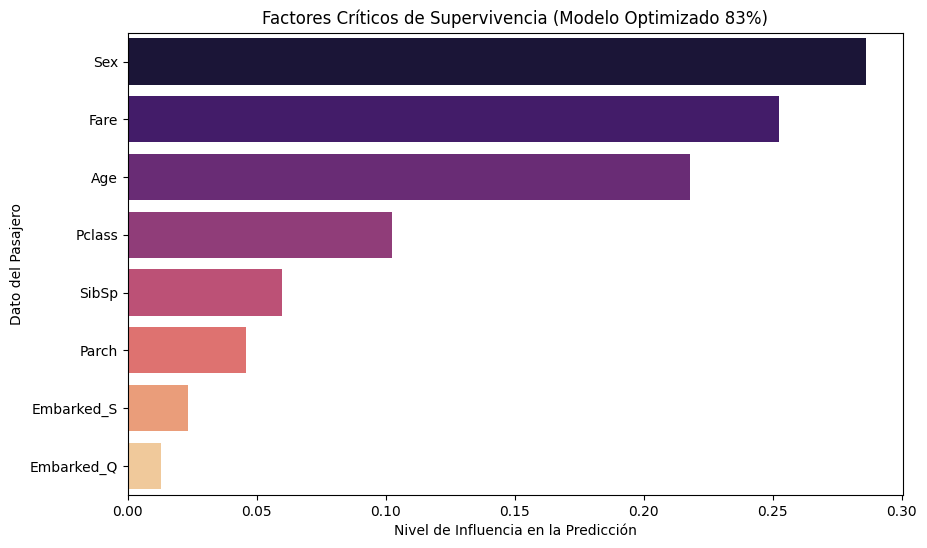

💡 La variable determinante sigue siendo: Sex


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. OBTENER IMPORTANCIAS
# [Explicación]: Extraemos los pesos que el mejor modelo asigna a cada columna.
importancias = mejor_modelo.feature_importances_
columnas = X.columns

# 2. CREAR TABLA PARA GRAFICAR
# [Explicación]: Ordenamos de mayor a menor importancia para que el gráfico sea legible.
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. CREAR GRÁFICO PROFESIONAL
# [Explicación]: Usamos 'magma' como paleta de colores para resaltar las variables críticas.
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, hue='Variable', palette='magma', legend=False)

plt.title('Factores Críticos de Supervivencia (Modelo Optimizado 83%)')
plt.xlabel('Nivel de Influencia en la Predicción')
plt.ylabel('Dato del Pasajero')
plt.show()

# 4. REPORTE POR CONSOLA
# [Explicación]: Imprimimos la variable ganadora para confirmarlo.
variable_top = df_importancia.iloc[0]['Variable']
print(f"💡 La variable determinante sigue siendo: {variable_top}")